# Demo 1 — Federated Learning: Medical Action Recognition

Focused training on **10 medical/safety-relevant actions** from NTU RGB+D 60  
for reliable **fall detection** and health monitoring.

**10 Classes:**
- Medical (7): falling, staggering, touch head (headache), touch chest (heart pain), touch back (backache), touch neck (neckache), nausea/vomiting
- Normal context (3): standing up, sitting down, walking towards each other

**FL Setup:** 5 clients, Dirichlet α=0.5, 50 rounds FedAvg + BN calibration  
**Warm-start:** 5 epochs centralized pretraining  
**Runtime → T4 GPU** before running (~25 min total)

## 1. Setup

In [1]:
!pip install -q onnx onnxsim onnxruntime scikit-learn

import torch
print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
assert torch.cuda.is_available(), "No GPU! Runtime → Change runtime type → T4 GPU"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 104.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 115.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 102.8 MB/s eta 0:00:0000:0100:01
PyTorch 2.10.0+cu128  |  CUDA: True
GPU: Tesla T4


## 2. Download NTU-60 Data & Filter Medical Subset

In [2]:
import os, pickle, time
import numpy as np
from collections import Counter, defaultdict

data_dir = 'data/nturgbd'
pkl_path = f'{data_dir}/ntu60_hrnet.pkl'

if not os.path.exists(pkl_path):
    os.makedirs(data_dir, exist_ok=True)
    !wget -q --show-progress -O {pkl_path} \
        https://download.openmmlab.com/mmaction/pyskl/data/nturgbd/ntu60_hrnet.pkl
    print(f'Downloaded: {pkl_path}')
else:
    print(f'Already exists: {pkl_path}')

with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

split_info = data['split']
annotations = data['annotations']
print(f'Total NTU-60 annotations: {len(annotations)}')

# ── Define medical-focused subset ──
# Original NTU-60 indices → our 10-class labels
MEDICAL_CLASS_MAP = {
    # Medical actions (7)
    42: 0,   # falling
    41: 1,   # staggering
    43: 2,   # touch head (headache)
    44: 3,   # touch chest (heart pain)
    45: 4,   # touch back (backache)
    46: 5,   # touch neck (neckache)
    47: 6,   # nausea or vomiting
    # Normal context actions (3)
    8:  7,   # standing up
    7:  8,   # sitting down
    58: 9,   # walking towards each other
}

MEDICAL_LABELS = [
    'falling',
    'staggering',
    'touch head (headache)',
    'touch chest (heart pain)',
    'touch back (backache)',
    'touch neck (neckache)',
    'nausea or vomiting',
    'standing up',
    'sitting down',
    'walking towards',
]
NUM_CLASSES = len(MEDICAL_LABELS)

# Filter annotations
selected_classes = set(MEDICAL_CLASS_MAP.keys())
medical_anns = [ann for ann in annotations if ann['label'] in selected_classes]
print(f'\nFiltered to {len(medical_anns)} medical/safety samples ({NUM_CLASSES} classes)')

# Show distribution
for orig_cls, new_cls in sorted(MEDICAL_CLASS_MAP.items(), key=lambda x: x[1]):
    count = sum(1 for a in medical_anns if a['label'] == orig_cls)
    tag = '🏥' if new_cls < 7 else '🟢'
    print(f'  {tag} [{new_cls}] {MEDICAL_LABELS[new_cls]:30s} ({count} samples)')

data/nturgbd/ntu60_ 100%[===================>] 672.72M  36.7MB/s    in 20s     
Downloaded: data/nturgbd/ntu60_hrnet.pkl
Total NTU-60 annotations: 56578

Filtered to 9444 medical/safety samples (10 classes)
  🏥 [0] falling                        (946 samples)
  🏥 [1] staggering                     (947 samples)
  🏥 [2] touch head (headache)          (946 samples)
  🏥 [3] touch chest (heart pain)       (947 samples)
  🏥 [4] touch back (backache)          (948 samples)
  🏥 [5] touch neck (neckache)          (948 samples)
  🏥 [6] nausea or vomiting             (946 samples)
  🟢 [7] standing up                    (936 samples)
  🟢 [8] sitting down                   (941 samples)
  🟢 [9] walking towards                (939 samples)


## 3. Preprocessing

In [3]:
def prenormalize_2d(keypoint, keypoint_score, img_shape=(1080, 1920), threshold=0.01):
    kp = keypoint.astype(np.float32).copy()
    score = keypoint_score.astype(np.float32)
    kp = np.concatenate([kp, score[..., None]], axis=-1)
    mask_out = kp[..., 2] <= threshold
    h, w = img_shape
    kp[..., 0] = (kp[..., 0] - w / 2) / (w / 2)
    kp[..., 1] = (kp[..., 1] - h / 2) / (h / 2)
    kp[..., 0][mask_out] = 0
    kp[..., 1][mask_out] = 0
    return kp

def uniform_sample(keypoint, clip_len=100):
    M, T, V, C = keypoint.shape
    if T == clip_len: return keypoint
    inds = np.arange(clip_len) % T if T < clip_len else np.linspace(0, T-1, clip_len, dtype=int)
    return keypoint[:, inds]

def format_gcn_input(keypoint, num_person=2):
    M, T, V, C = keypoint.shape
    if M < num_person:
        pad = np.zeros((num_person - M, T, V, C), dtype=keypoint.dtype)
        keypoint = np.concatenate([keypoint, pad], axis=0)
    return keypoint[:num_person]

def preprocess_sample(ann, clip_len=100, num_person=2):
    img_shape = ann.get('img_shape', (1080, 1920))
    kp = prenormalize_2d(ann['keypoint'], ann['keypoint_score'], img_shape)
    kp = uniform_sample(kp, clip_len)
    return format_gcn_input(kp, num_person)

# Test
test_out = preprocess_sample(medical_anns[0])
print(f'Sample shape: {test_out.shape}')  # (2, 100, 17, 3)

Sample shape: (2, 100, 17, 3)


## 4. Build Train/Test Splits & Federated Partitioning

In [4]:
train_dirs = set(split_info['xsub_train'])
test_dirs = set(split_info['xsub_val'])

print('Preprocessing medical subset...')
t0 = time.time()

train_x, train_y, test_x, test_y = [], [], [], []
for ann in medical_anns:
    x = preprocess_sample(ann)
    new_label = MEDICAL_CLASS_MAP[ann['label']]
    if ann['frame_dir'] in train_dirs:
        train_x.append(x); train_y.append(new_label)
    elif ann['frame_dir'] in test_dirs:
        test_x.append(x); test_y.append(new_label)

train_x = np.stack(train_x).astype(np.float32)
train_y = np.array(train_y, dtype=np.int64)
test_x = np.stack(test_x).astype(np.float32)
test_y = np.array(test_y, dtype=np.int64)
print(f'Train: {train_x.shape}, Test: {test_x.shape} ({time.time()-t0:.1f}s)')

# ── Dirichlet non-IID split ──
NUM_CLIENTS = 5
ALPHA = 0.5

rng = np.random.RandomState(42)
label_indices = defaultdict(list)
for i, label in enumerate(train_y):
    label_indices[int(label)].append(i)

client_indices = {i: [] for i in range(NUM_CLIENTS)}
for cls in range(NUM_CLASSES):
    idxs = np.array(label_indices[cls])
    rng.shuffle(idxs)
    proportions = rng.dirichlet([ALPHA] * NUM_CLIENTS)
    proportions = np.cumsum(proportions) / proportions.sum()
    splits = np.split(idxs, (proportions[:-1] * len(idxs)).astype(int))
    for cid, chunk in enumerate(splits):
        client_indices[cid].extend(chunk.tolist())

print(f'\nDirichlet split (α={ALPHA}):')
for cid in range(NUM_CLIENTS):
    ci = client_indices[cid]
    labels = train_y[ci]
    n_cls = len(set(labels))
    print(f'  Client {cid}: {len(ci):4d} samples, {n_cls}/{NUM_CLASSES} classes')

# Save
fed_dir = 'fed_data_medical'
os.makedirs(fed_dir, exist_ok=True)
for cid in range(NUM_CLIENTS):
    ci = np.array(client_indices[cid], dtype=int)
    np.savez_compressed(f'{fed_dir}/client_{cid}.npz', x=train_x[ci], y=train_y[ci])
np.savez_compressed(f'{fed_dir}/test.npz', x=test_x, y=test_y)
print(f'Saved to {fed_dir}/')

Preprocessing medical subset...
Train: (6695, 2, 100, 17, 3), Test: (2749, 2, 100, 17, 3) (1.4s)

Dirichlet split (α=0.5):
  Client 0: 1798 samples, 9/10 classes
  Client 1: 1078 samples, 10/10 classes
  Client 2: 1648 samples, 10/10 classes
  Client 3: 1253 samples, 10/10 classes
  Client 4:  918 samples, 10/10 classes
Saved to fed_data_medical/


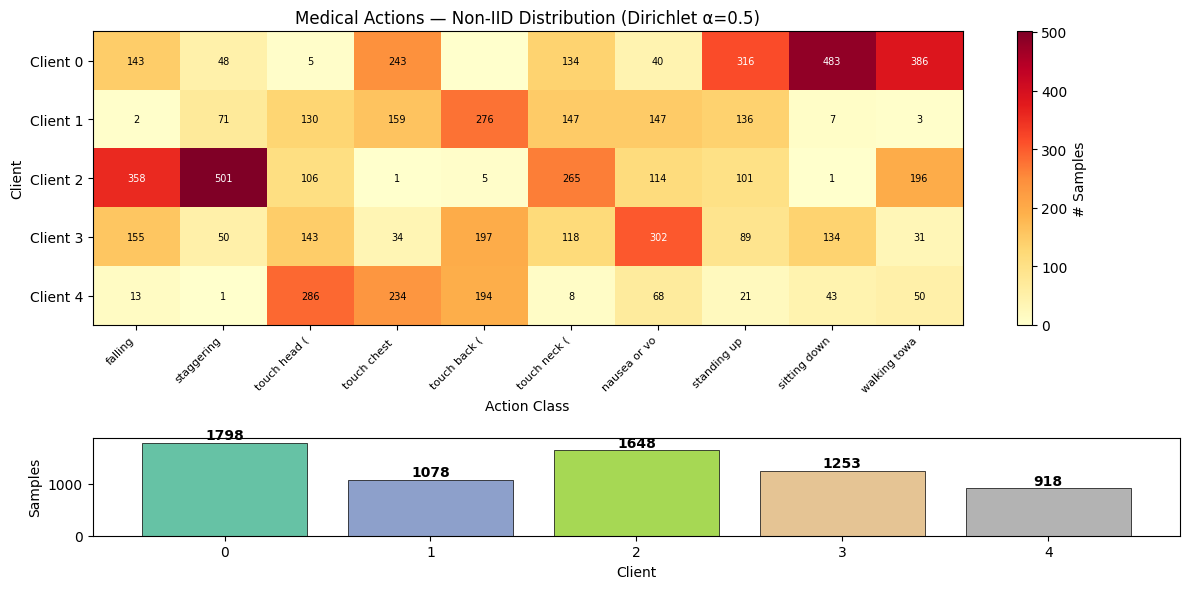

In [5]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 10})
os.makedirs('outputs', exist_ok=True)

dist_matrix = np.zeros((NUM_CLIENTS, NUM_CLASSES), dtype=int)
for cid in range(NUM_CLIENTS):
    for idx in client_indices[cid]:
        dist_matrix[cid, int(train_y[idx])] += 1

fig, axes = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={'height_ratios': [3, 1]})

im = axes[0].imshow(dist_matrix, aspect='auto', cmap='YlOrRd', interpolation='nearest')
axes[0].set_xlabel('Action Class')
axes[0].set_ylabel('Client')
axes[0].set_yticks(range(NUM_CLIENTS))
axes[0].set_yticklabels([f'Client {i}' for i in range(NUM_CLIENTS)])
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].set_xticklabels([l[:12] for l in MEDICAL_LABELS], rotation=45, ha='right', fontsize=8)
axes[0].set_title(f'Medical Actions — Non-IID Distribution (Dirichlet α={ALPHA})')
plt.colorbar(im, ax=axes[0], label='# Samples')

# Annotate counts
for cid in range(NUM_CLIENTS):
    for cls in range(NUM_CLASSES):
        val = dist_matrix[cid, cls]
        if val > 0:
            axes[0].text(cls, cid, str(val), ha='center', va='center', fontsize=7,
                        color='white' if val > dist_matrix.max()*0.6 else 'black')

client_totals = dist_matrix.sum(axis=1)
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLIENTS))
bars = axes[1].bar(range(NUM_CLIENTS), client_totals, color=colors, edgecolor='k', linewidth=0.5)
for bar, total in zip(bars, client_totals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{total}', ha='center', va='bottom', fontweight='bold')
axes[1].set_xlabel('Client')
axes[1].set_ylabel('Samples')
axes[1].set_xticks(range(NUM_CLIENTS))

plt.tight_layout()
plt.savefig('outputs/medical_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Definition (STGCN++)

In [8]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

COCO_INWARD = [
    (15, 13), (13, 11), (16, 14), (14, 12),
    (11, 5), (12, 6), (9, 7), (7, 5), (10, 8), (8, 6),
    (5, 0), (6, 0), (1, 0), (3, 1), (2, 0), (4, 2),
]
COCO_NUM_JOINTS = 17
COCO_CENTER = 0

def _build_adjacency(num_node, edges, center):
    def _normalize(mx):
        d = mx.sum(axis=0); d[d == 0] = 1; return mx / d
    I = np.eye(num_node, dtype=np.float32)
    inward = np.zeros((num_node, num_node), dtype=np.float32)
    outward = np.zeros((num_node, num_node), dtype=np.float32)
    hop = np.full(num_node, 1e9, dtype=int); hop[center] = 0
    adj = {i: [] for i in range(num_node)}
    for u, v in edges: adj[u].append(v); adj[v].append(u)
    queue = [center]
    while queue:
        cur = queue.pop(0)
        for nb in adj[cur]:
            if hop[nb] > hop[cur] + 1: hop[nb] = hop[cur] + 1; queue.append(nb)
    for u, v in edges:
        if hop[u] < hop[v]: inward[v, u] = 1
        else: outward[u, v] = 1
    return np.stack([_normalize(I), _normalize(inward), _normalize(outward)])

def get_coco_adjacency():
    return _build_adjacency(COCO_NUM_JOINTS, COCO_INWARD, COCO_CENTER)


class MsTCN(nn.Module):
    def __init__(self, in_ch, out_ch, dilations=(1, 2, 3, 4), stride=1, dropout=0.0):
        super().__init__()
        mid = out_ch // (len(dilations) + 2)
        rem = out_ch - mid * (len(dilations) + 2)
        self.branches = nn.ModuleList()
        for d in dilations:
            self.branches.append(nn.Sequential(
                nn.Conv2d(in_ch, mid, 1), nn.BatchNorm2d(mid), nn.ReLU(True),
                nn.Conv2d(mid, mid, (3,1), stride=(stride,1), padding=(d,0), dilation=(d,1)),
                nn.BatchNorm2d(mid)))
        self.branches.append(nn.Sequential(
            nn.Conv2d(in_ch, mid, 1), nn.BatchNorm2d(mid), nn.ReLU(True),
            nn.MaxPool2d((3,1), stride=(stride,1), padding=(1,0)), nn.BatchNorm2d(mid)))
        self.branches.append(nn.Sequential(
            nn.Conv2d(in_ch, mid + rem, 1), nn.BatchNorm2d(mid + rem)))
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        outs = [br(x) for br in self.branches]
        mt = min(o.size(2) for o in outs)
        return self.drop(torch.cat([o[:,:,:mt,:] for o in outs], dim=1))


class UnitGCN(nn.Module):
    def __init__(self, in_ch, out_ch, A, adaptive=True):
        super().__init__()
        K = A.size(0); self.K = K
        self.register_buffer('A', A)
        self.conv = nn.ModuleList([nn.Conv2d(in_ch, out_ch, 1) for _ in range(K)])
        self.PA = nn.Parameter(A.clone()) if adaptive else None
        self.bn = nn.BatchNorm2d(out_ch)
        self.res = nn.Sequential(nn.Conv2d(in_ch, out_ch, 1), nn.BatchNorm2d(out_ch)) if in_ch != out_ch else nn.Identity()
        for m in self.conv:
            nn.init.kaiming_normal_(m.weight, mode='fan_out')
            if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, x):
        adj = self.A + self.PA if self.PA is not None else self.A
        out = sum(torch.einsum('nctv,vw->nctw', self.conv[k](x), adj[k]) for k in range(self.K))
        return F.relu(self.bn(out) + self.res(x), inplace=True)


class STGCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, A, stride=1, dropout=0.0):
        super().__init__()
        self.gcn = UnitGCN(in_ch, out_ch, A)
        self.tcn = MsTCN(out_ch, out_ch, stride=stride, dropout=dropout)
        self.residual = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1), nn.BatchNorm2d(out_ch),
            nn.AvgPool2d((stride,1)) if stride > 1 else nn.Identity()
        ) if in_ch != out_ch or stride != 1 else nn.Identity()
    def forward(self, x):
        return F.relu(self.tcn(self.gcn(x)) + self.residual(x), inplace=True)


class STGCN(nn.Module):
    def __init__(self, num_classes=10, in_channels=3, base_channels=64,
                 num_stages=6, inflate_stages=None, down_stages=None,
                 num_person=2, dropout=0.0):
        super().__init__()
        if inflate_stages is None: inflate_stages = [3, 5]
        if down_stages is None: down_stages = [3, 5]
        self.num_person = num_person
        A = torch.tensor(get_coco_adjacency(), dtype=torch.float32)
        self.data_bn = nn.BatchNorm1d(in_channels * COCO_NUM_JOINTS)
        channels = [base_channels]
        for i in range(1, num_stages):
            channels.append(channels[-1] * 2 if i in inflate_stages else channels[-1])
        self.blocks = nn.ModuleList()
        c_in = in_channels
        for i in range(num_stages):
            self.blocks.append(STGCNBlock(c_in, channels[i], A,
                               stride=2 if i in down_stages else 1, dropout=dropout))
            c_in = channels[i]
        self.out_channels = channels[-1]
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc = nn.Linear(self.out_channels, num_classes)
        nn.init.normal_(self.fc.weight, 0, math.sqrt(2.0 / num_classes))
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        N, M, T, V, C = x.shape
        x = x.permute(0,1,4,2,3).contiguous().view(N*M, C, T, V)
        x = x.permute(0,1,3,2).contiguous().view(N*M, C*V, T)
        x = self.data_bn(x)
        x = x.view(N*M, C, V, T).permute(0,1,3,2).contiguous()
        for block in self.blocks:
            x = block(x)
        x = self.pool(x).view(N, M, self.out_channels).mean(dim=1)
        return self.fc(self.drop(x))

def build_model(num_classes=10, in_channels=3, **kw):
    return STGCN(num_classes=num_classes, in_channels=in_channels, **kw)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

_m = build_model(num_classes=NUM_CLASSES, dropout=0.3)
print(f'STGCN++ params: {count_parameters(_m):,}')
print(f'Output shape: {_m(torch.randn(2, 2, 100, 17, 3)).shape}')
del _m

STGCN++ params: 443,222
Output shape: torch.Size([2, 10])


## 6. Centralized Warm-Start (5 epochs)

In [9]:
from torch.utils.data import DataLoader, TensorDataset

WARMUP_EPOCHS = 2
BATCH_SIZE = 64
DEVICE = 'cuda'

model_kwargs = dict(base_channels=64, num_stages=6, num_person=2, dropout=0.3)

warmup_model = build_model(num_classes=NUM_CLASSES, in_channels=3, **model_kwargs)
warmup_model.to(DEVICE)
print(f'Model: {count_parameters(warmup_model):,} params')

warmup_loader = DataLoader(
    TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader_warmup = DataLoader(
    TensorDataset(torch.from_numpy(test_x), torch.from_numpy(test_y)),
    batch_size=128)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(warmup_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

print(f'\n{"="*50}')
print(f'Centralized Warm-Start: {WARMUP_EPOCHS} epochs')
print(f'{"="*50}')

warmup_history = []
t0 = time.time()

for epoch in range(1, WARMUP_EPOCHS + 1):
    warmup_model.train()
    correct, total, running_loss = 0, 0, 0.0
    for xb, yb in warmup_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = warmup_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * yb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
    train_acc = correct / total
    train_loss = running_loss / total

    warmup_model.eval()
    t_correct, t_total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader_warmup:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            t_correct += (warmup_model(xb).argmax(1) == yb).sum().item()
            t_total += yb.size(0)
    test_acc = t_correct / t_total

    warmup_history.append({'epoch': epoch, 'train_acc': train_acc, 'test_acc': test_acc, 'loss': train_loss})
    print(f'  Epoch {epoch}/{WARMUP_EPOCHS}  loss={train_loss:.4f}  train={train_acc:.4f}  test={test_acc:.4f}')

print(f'\nWarm-start done in {time.time()-t0:.0f}s — Test acc: {test_acc:.4f}')
warmup_sd = {k: v.cpu() for k, v in warmup_model.state_dict().items()}
torch.save(warmup_sd, 'outputs/warmstart_medical.pt')
del warmup_model; torch.cuda.empty_cache()

Model: 443,222 params

Centralized Warm-Start: 2 epochs
  Epoch 1/2  loss=2.1336  train=0.2894  test=0.3634
  Epoch 2/2  loss=1.3190  train=0.4983  test=0.5249

Warm-start done in 118s — Test acc: 0.5249


## 7. Federated Training — 50 Rounds

In [10]:
import copy, json
from collections import OrderedDict
from pathlib import Path
from IPython.display import display, HTML

NUM_ROUNDS = 35
EPOCHS_PER_ROUND = 1
LR = 0.01

global_model = build_model(num_classes=NUM_CLASSES, in_channels=3, **model_kwargs)
warmstart_path = 'outputs/warmstart_medical.pt'
if os.path.exists(warmstart_path):
    global_model.load_state_dict(torch.load(warmstart_path, map_location='cpu'))
    print(f'✓ Loaded warm-start from {warmstart_path}')

# Load client data
fed_dir = Path('fed_data_medical')
client_loaders = []
all_train_x_parts, all_train_y_parts = [], []
for cid in range(NUM_CLIENTS):
    d = np.load(fed_dir / f'client_{cid}.npz')
    xc, yc = d['x'].astype(np.float32), d['y'].astype(np.int64)
    all_train_x_parts.append(xc)
    all_train_y_parts.append(yc)
    ds = TensorDataset(torch.from_numpy(xc), torch.from_numpy(yc))
    client_loaders.append(DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True))

calib_loader = DataLoader(
    TensorDataset(torch.from_numpy(np.concatenate(all_train_x_parts)),
                  torch.from_numpy(np.concatenate(all_train_y_parts))),
    batch_size=128, shuffle=True)
test_d = np.load(fed_dir / 'test.npz')
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(test_d['x'].astype(np.float32)),
                  torch.from_numpy(test_d['y'].astype(np.int64))),
    batch_size=128)

def calibrate_bn(model, loader, device, max_batches=30):
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
            m.reset_running_stats(); m.momentum = None
    model.train()
    with torch.no_grad():
        for i, (xb, _) in enumerate(loader):
            if i >= max_batches: break
            model(xb.to(device))

# ── Training loop ──
device = torch.device(DEVICE)
criterion = nn.CrossEntropyLoss()
history = []
client_acc_matrix = []
round_times = []
best_test_acc = 0.0
best_sd = None

dashboard_handle = display(HTML(''), display_id=True)

print(f'\n{"="*60}')
print(f'Federated Training: {NUM_ROUNDS} rounds, {NUM_CLIENTS} clients')
print(f'{"="*60}')
t0_total = time.time()

for rnd in range(1, NUM_ROUNDS + 1):
    t0_round = time.time()
    lr = LR
    if rnd > 35: lr = LR * 0.01
    elif rnd > 20: lr = LR * 0.1

    global_sd = copy.deepcopy(global_model.state_dict())
    client_weights, client_accs, client_losses = [], [], []

    for cid in range(NUM_CLIENTS):
        local_model = build_model(num_classes=NUM_CLASSES, in_channels=3, **model_kwargs)
        local_model.load_state_dict(global_sd)
        local_model.to(device).train()
        optimizer = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
        correct, total, running_loss = 0, 0, 0.0
        for _ in range(EPOCHS_PER_ROUND):
            for xb, yb in client_loaders[cid]:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                logits = local_model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()
                correct += (logits.argmax(1) == yb).sum().item()
                total += yb.size(0)
                running_loss += loss.item() * yb.size(0)

        client_accs.append(correct / max(total, 1))
        client_losses.append(running_loss / max(total, 1))
        client_weights.append((total, {k: v.cpu() for k, v in local_model.state_dict().items()}))

    # FedAvg
    all_keys = list(global_sd.keys())
    total_samples = sum(n for n, _ in client_weights)
    new_sd = OrderedDict()
    for k in all_keys:
        new_sd[k] = sum(n * sd[k].float() for n, sd in client_weights) / total_samples
    gsd = global_model.state_dict()
    for k in all_keys:
        gsd[k] = new_sd[k].to(gsd[k].dtype)
    global_model.load_state_dict(gsd)

    # BN calibration
    global_model.to(device)
    calibrate_bn(global_model, calib_loader, device)

    # Test
    global_model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            test_correct += (global_model(xb).argmax(1) == yb).sum().item()
            test_total += yb.size(0)
    test_acc = test_correct / max(test_total, 1)
    global_model.cpu()

    # Save best
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_sd = copy.deepcopy(global_model.state_dict())

    round_time = time.time() - t0_round
    round_times.append(round_time)
    client_acc_matrix.append(client_accs.copy())

    history.append({
        'round': rnd,
        'mean_client_acc': float(np.mean(client_accs)),
        'worst_client_acc': float(np.min(client_accs)),
        'best_client_acc': float(np.max(client_accs)),
        'mean_client_loss': float(np.mean(client_losses)),
        'test_acc': float(test_acc),
        'lr': lr,
        'client_accs': [float(a) for a in client_accs],
        'client_losses': [float(l) for l in client_losses],
    })

    # Dashboard
    rnd_info = history[-1]
    pct = rnd / NUM_ROUNDS * 100
    html = f'<div style="font-family:monospace; background:#1e1e1e; color:#d4d4d4; padding:12px; border-radius:8px;">'
    html += f'<h3 style="color:#569cd6; margin:0 0 8px 0;">🏥 Medical FL — Round {rnd}/{NUM_ROUNDS}</h3>'
    html += f'<div style="background:#333; border-radius:4px; height:20px; margin-bottom:10px;">'
    html += f'<div style="background:linear-gradient(90deg,#e74c3c,#e67e22); width:{pct}%; height:100%; border-radius:4px; '
    html += f'text-align:center; color:white; font-size:12px; line-height:20px;">{pct:.0f}%</div></div>'
    html += f'<b style="color:#4ec9b0">Test: {test_acc:.4f}</b> | '
    html += f'Mean: {rnd_info["mean_client_acc"]:.4f} | '
    html += f'Best ever: {best_test_acc:.4f} | '
    html += f'LR: {lr} | Time: {round_time:.1f}s'
    html += '</div>'
    dashboard_handle.update(HTML(html))

elapsed = time.time() - t0_total
print(f'\n✓ Training done in {elapsed:.0f}s ({elapsed/60:.1f} min)')
print(f'Best test accuracy: {best_test_acc:.4f}')
print(f'Final test accuracy: {history[-1]["test_acc"]:.4f}')

# Use best model
if best_sd is not None:
    global_model.load_state_dict(best_sd)
    print(f'Loaded best checkpoint (acc={best_test_acc:.4f})')

✓ Loaded warm-start from outputs/warmstart_medical.pt



Federated Training: 35 rounds, 5 clients

✓ Training done in 2604s (43.4 min)
Best test accuracy: 0.7846
Final test accuracy: 0.7439
Loaded best checkpoint (acc=0.7846)


In [11]:
# Save checkpoint & history
torch.save(global_model.cpu().state_dict(), 'outputs/global_model_medical.pt')
full_history = {'warmup': warmup_history, 'fl': history, 'client_acc_matrix': client_acc_matrix}
with open('outputs/fl_history_medical.json', 'w') as f:
    json.dump(full_history, f, indent=2)
print('Saved: outputs/global_model_medical.pt, fl_history_medical.json')

Saved: outputs/global_model_medical.pt, fl_history_medical.json


## 8. Visualization

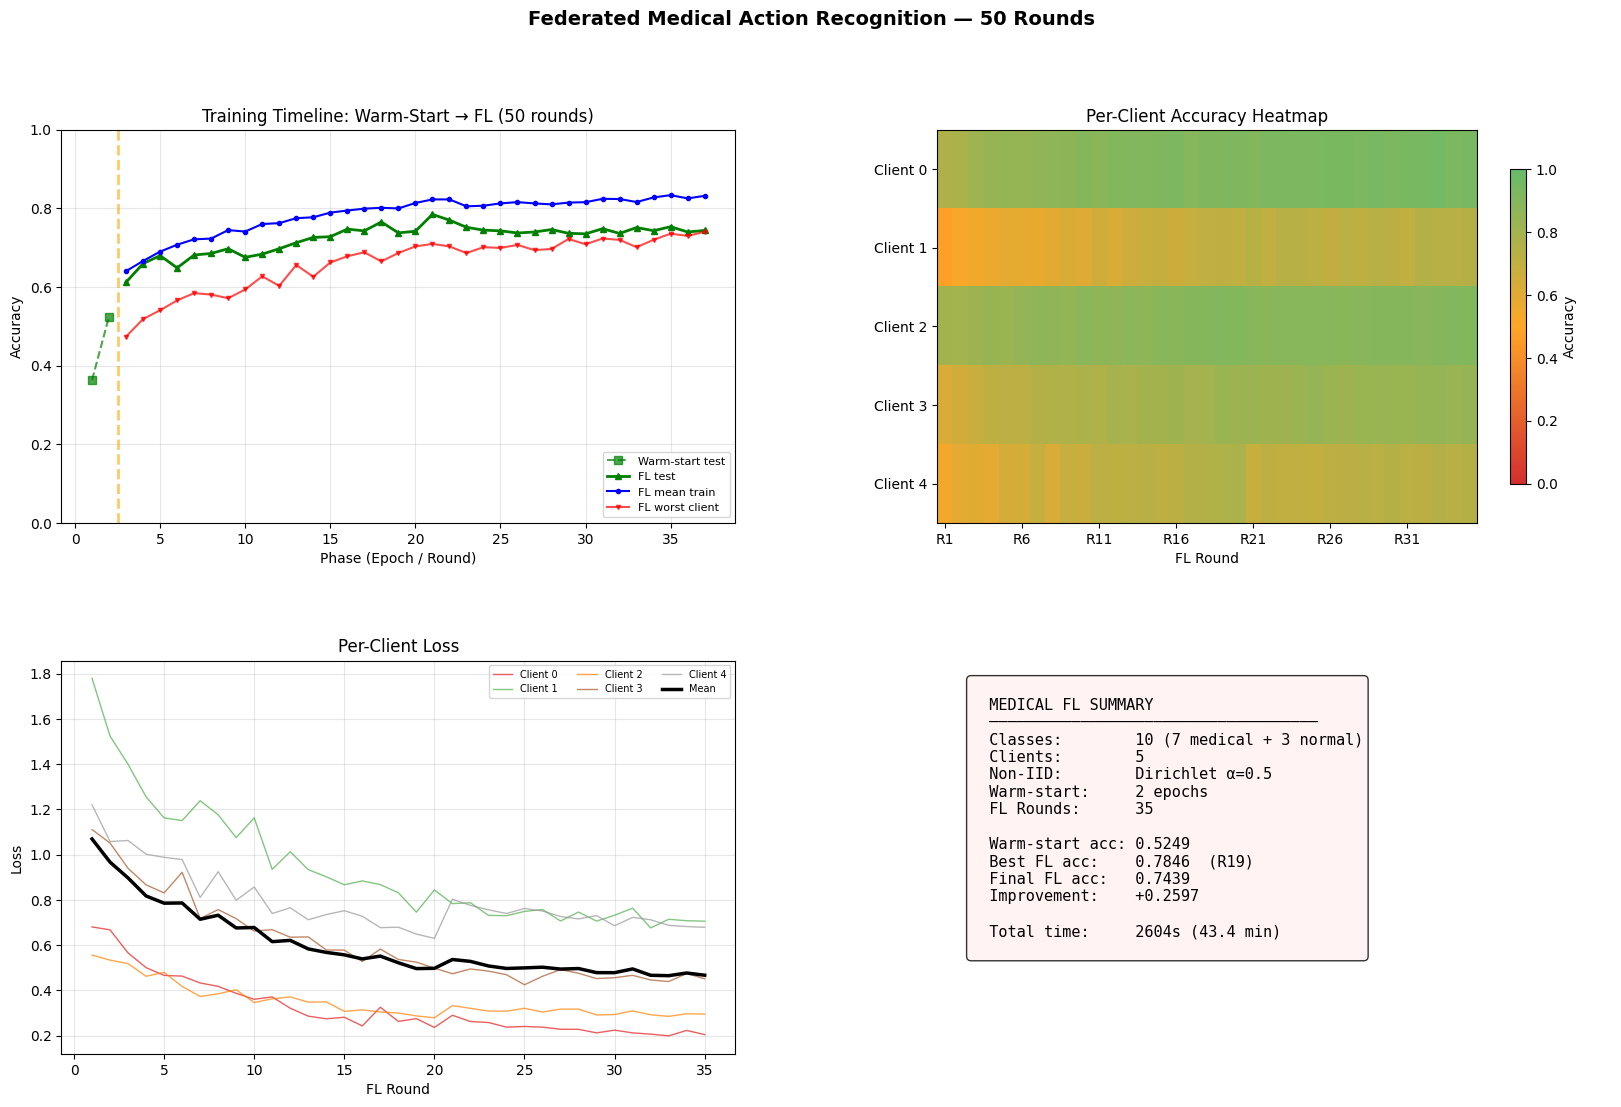

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# Panel 1: Training timeline
ax1 = fig.add_subplot(gs[0, 0])
ws_epochs = [h['epoch'] for h in warmup_history]
ax1.plot(ws_epochs, [h['test_acc'] for h in warmup_history], 'g--s', markersize=6, label='Warm-start test', alpha=0.7)
offset = len(warmup_history)
fl_rounds = [offset + h['round'] for h in history]
ax1.plot(fl_rounds, [h['test_acc'] for h in history], 'g-^', markersize=4, label='FL test', linewidth=2)
ax1.plot(fl_rounds, [h['mean_client_acc'] for h in history], 'b-o', markersize=3, label='FL mean train', linewidth=1.5)
ax1.plot(fl_rounds, [h['worst_client_acc'] for h in history], 'r-v', markersize=3, label='FL worst client', alpha=0.7)
ax1.set_ylim(0, 1.0)
ax1.axvline(x=offset + 0.5, color='orange', linestyle='--', linewidth=2, alpha=0.6)
ax1.set_xlabel('Phase (Epoch / Round)')
ax1.set_ylabel('Accuracy')
ax1.set_title('Training Timeline: Warm-Start → FL (50 rounds)')
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Panel 2: Client accuracy heatmap
ax2 = fig.add_subplot(gs[0, 1])
cam = np.array(client_acc_matrix)
cmap_rg = LinearSegmentedColormap.from_list('rg', ['#d32f2f', '#ffa726', '#66bb6a'], N=256)
im = ax2.imshow(cam.T, aspect='auto', cmap=cmap_rg, vmin=0, vmax=1, interpolation='nearest')
ax2.set_xticks(range(0, len(history), 5))
ax2.set_xticklabels([f'R{h["round"]}' for h in history[::5]])
ax2.set_yticks(range(NUM_CLIENTS))
ax2.set_yticklabels([f'Client {i}' for i in range(NUM_CLIENTS)])
ax2.set_xlabel('FL Round')
ax2.set_title('Per-Client Accuracy Heatmap')
plt.colorbar(im, ax=ax2, label='Accuracy', shrink=0.8)

# Panel 3: Loss curves
ax3 = fig.add_subplot(gs[1, 0])
colors = plt.cm.Set1(np.linspace(0, 1, NUM_CLIENTS))
for cid in range(NUM_CLIENTS):
    losses = [h['client_losses'][cid] for h in history]
    ax3.plot(range(1, len(losses)+1), losses, '-', color=colors[cid], label=f'Client {cid}', linewidth=1, alpha=0.7)
mean_losses = [h['mean_client_loss'] for h in history]
ax3.plot(range(1, len(mean_losses)+1), mean_losses, 'k-', label='Mean', linewidth=2.5, zorder=10)
ax3.set_xlabel('FL Round')
ax3.set_ylabel('Loss')
ax3.set_title('Per-Client Loss')
ax3.legend(fontsize=7, ncol=3)
ax3.grid(True, alpha=0.3)

# Panel 4: Summary
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
best_round = max(history, key=lambda h: h['test_acc'])
summary = f"""
  MEDICAL FL SUMMARY
  {'─' * 36}
  Classes:        {NUM_CLASSES} (7 medical + 3 normal)
  Clients:        {NUM_CLIENTS}
  Non-IID:        Dirichlet α={ALPHA}
  Warm-start:     {WARMUP_EPOCHS} epochs
  FL Rounds:      {NUM_ROUNDS}

  Warm-start acc: {warmup_history[-1]['test_acc']:.4f}
  Best FL acc:    {best_round['test_acc']:.4f}  (R{best_round['round']})
  Final FL acc:   {history[-1]['test_acc']:.4f}
  Improvement:    {best_round['test_acc'] - warmup_history[-1]['test_acc']:+.4f}

  Total time:     {sum(round_times):.0f}s ({sum(round_times)/60:.1f} min)
"""
ax4.text(0.05, 0.95, summary, transform=ax4.transAxes, fontsize=11,
         fontfamily='monospace', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='#fff0f0', alpha=0.8))

plt.suptitle('Federated Medical Action Recognition — 50 Rounds', fontsize=14, fontweight='bold')
plt.savefig('outputs/medical_fl_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Confusion Matrix — Focus on Fall Detection

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import onnxruntime as ort

# Run inference with best model
model = build_model(num_classes=NUM_CLASSES, in_channels=3, **model_kwargs)
model.load_state_dict(torch.load('outputs/global_model_medical.pt', map_location='cpu'))
model.to(DEVICE).eval()

test_d = np.load('fed_data_medical/test.npz')
x_t, y_t = test_d['x'].astype(np.float32), test_d['y']

# Batch inference on GPU (avoid single huge forward pass)
all_preds = []
with torch.no_grad():
    for i in range(0, len(x_t), 128):
        batch = torch.from_numpy(x_t[i:i+128]).to(DEVICE)
        logits = model(batch)
        all_preds.append(logits.argmax(1).cpu().numpy())
preds = np.concatenate(all_preds)
model.cpu()

acc = (preds == y_t).mean()
print(f'Test accuracy: {acc:.4f} ({(preds == y_t).sum()}/{len(y_t)})')

# Fall detection specific metrics
fall_true = (y_t == 0)  # class 0 = falling
fall_pred = (preds == 0)
fall_tp = (fall_true & fall_pred).sum()
fall_fn = (fall_true & ~fall_pred).sum()
fall_fp = (~fall_true & fall_pred).sum()
fall_tn = (~fall_true & ~fall_pred).sum()
fall_recall = fall_tp / max(fall_tp + fall_fn, 1)
fall_precision = fall_tp / max(fall_tp + fall_fp, 1)
fall_f1 = 2 * fall_precision * fall_recall / max(fall_precision + fall_recall, 1e-8)

print(f'\n🏥 FALL DETECTION:')
print(f'  Recall (sensitivity):  {fall_recall:.1%} — {fall_tp}/{fall_tp+fall_fn} falls caught')
print(f'  Precision:             {fall_precision:.1%}')
print(f'  F1 score:              {fall_f1:.4f}')
if fall_fn > 0:
    missed_as = Counter(preds[fall_true & ~fall_pred])
    print(f'  Missed falls classified as:')
    for cls, cnt in missed_as.most_common():
        print(f'    {MEDICAL_LABELS[cls]:30s} ({cnt} times)')

# Full report
print(f'\n{"="*60}')
print(classification_report(y_t, preds, target_names=MEDICAL_LABELS, digits=3))

Test accuracy: 0.7846 (2157/2749)

🏥 FALL DETECTION:
  Recall (sensitivity):  86.9% — 239/275 falls caught
  Precision:             98.8%
  F1 score:              0.9246
  Missed falls classified as:
    sitting down                   (28 times)
    staggering                     (8 times)

                          precision    recall  f1-score   support

                 falling      0.988     0.869     0.925       275
              staggering      0.865     0.768     0.814       276
   touch head (headache)      0.872     0.370     0.519       276
touch chest (heart pain)      0.577     0.707     0.635       276
   touch back (backache)      0.702     0.768     0.734       276
   touch neck (neckache)      0.628     0.837     0.717       276
      nausea or vomiting      0.903     0.640     0.749       275
             standing up      0.964     0.982     0.973       273
            sitting down      0.655     0.985     0.787       273
         walking towards      1.000     0.927  

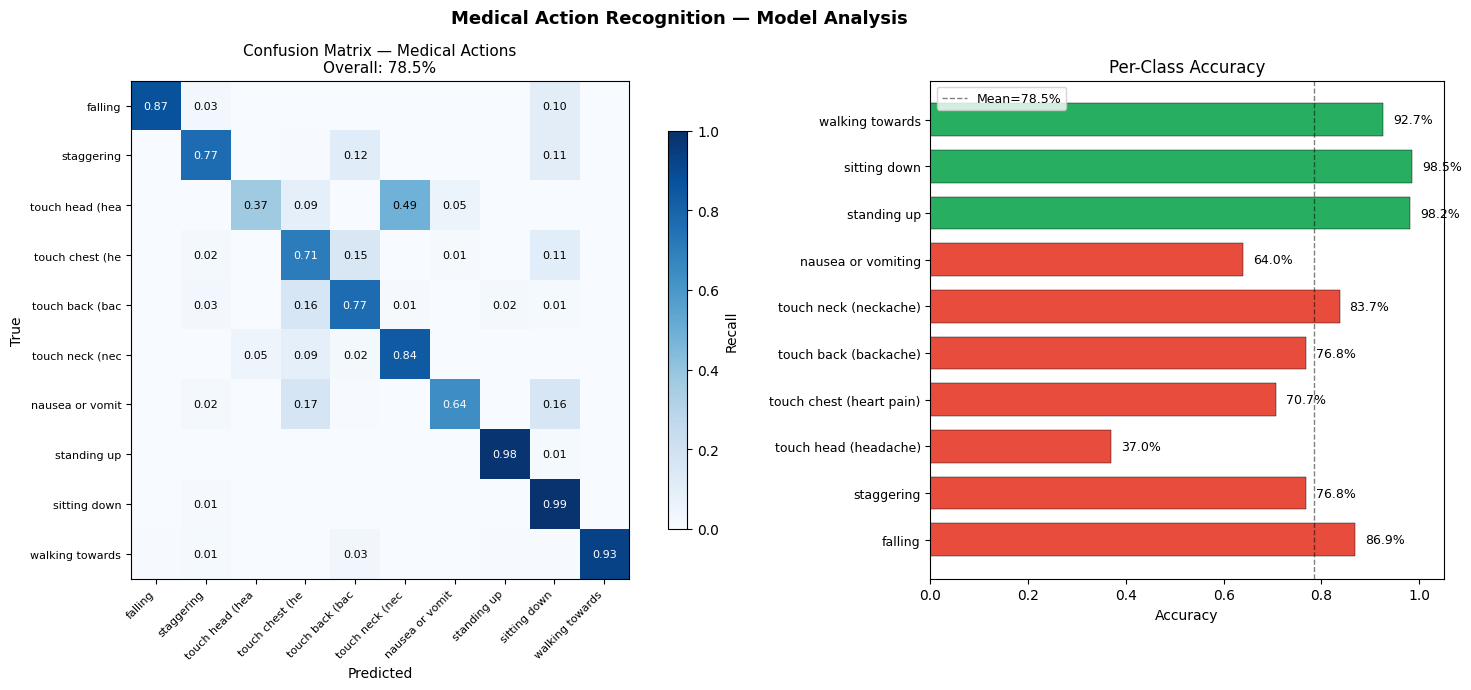

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1.5, 1]})

# Confusion matrix
cm = confusion_matrix(y_t, preds, labels=range(NUM_CLASSES))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

im = axes[0].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
# Annotate all cells (10×10 is small enough)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        val = cm_norm[i, j]
        if val > 0.01:
            color = 'white' if val > 0.5 else 'black'
            axes[0].text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].set_yticks(range(NUM_CLASSES))
axes[0].set_xticklabels([l[:15] for l in MEDICAL_LABELS], rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels([l[:15] for l in MEDICAL_LABELS], fontsize=8)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title(f'Confusion Matrix — Medical Actions\nOverall: {acc:.1%}', fontsize=11)
plt.colorbar(im, ax=axes[0], label='Recall', shrink=0.8)

# Per-class accuracy bar
class_acc = cm_norm.diagonal()
bar_colors = ['#e74c3c' if i < 7 else '#27ae60' for i in range(NUM_CLASSES)]
axes[1].barh(range(NUM_CLASSES), class_acc, color=bar_colors, height=0.7, edgecolor='k', linewidth=0.3)
axes[1].set_yticks(range(NUM_CLASSES))
axes[1].set_yticklabels(MEDICAL_LABELS, fontsize=9)
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Per-Class Accuracy')
axes[1].axvline(x=acc, color='k', linestyle='--', linewidth=1, alpha=0.5, label=f'Mean={acc:.1%}')
axes[1].set_xlim(0, 1.05)
axes[1].legend(fontsize=9)
# Annotate bars
for i, a in enumerate(class_acc):
    axes[1].text(a + 0.02, i, f'{a:.1%}', va='center', fontsize=9)

plt.suptitle('Medical Action Recognition — Model Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/medical_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Export ONNX & Label Map

In [17]:
model = build_model(num_classes=NUM_CLASSES, in_channels=3, **model_kwargs)
model.load_state_dict(torch.load('outputs/global_model_medical.pt', map_location='cpu'))
model.eval()

dummy = torch.randn(1, 2, 100, 17, 3)
onnx_path = 'outputs/stgcnpp_medical_federated.onnx'

torch.onnx.export(
    model, dummy, onnx_path,
    input_names=['skeleton'], output_names=['logits'],
    dynamic_axes={'skeleton': {0: 'batch'}, 'logits': {0: 'batch'}},
    opset_version=12, do_constant_folding=True, dynamo=False,
)
print(f'ONNX exported: {onnx_path}')

try:
    import onnx; from onnxsim import simplify as onnx_simplify
    m = onnx.load(onnx_path)
    simplified, ok = onnx_simplify(m)
    if ok: onnx.save(simplified, onnx_path); print('Simplified ✓')
except: print('Simplify skipped')

# Verify
import onnxruntime as ort
sess = ort.InferenceSession(onnx_path)
inp = sess.get_inputs()[0]
print(f'Input: {inp.name} {inp.shape}')
print(f'Output: {sess.get_outputs()[0].name} {sess.get_outputs()[0].shape}')

ort_out = sess.run(None, {'skeleton': dummy.numpy()})[0]
torch_out = model(dummy).detach().numpy()
diff = abs(ort_out - torch_out).max()
print(f'Max diff: {diff:.2e} {"✓" if diff < 1e-3 else "FAIL"}')
print(f'Model size: {os.path.getsize(onnx_path)/1024**2:.1f} MB')

# Label map
with open('outputs/label_map_medical.txt', 'w') as f:
    f.write('\n'.join(MEDICAL_LABELS) + '\n')
print(f'Label map: outputs/label_map_medical.txt ({NUM_CLASSES} classes)')

# Output files
print('\n── Output files ──')
for fn in ['outputs/stgcnpp_medical_federated.onnx',
           'outputs/global_model_medical.pt',
           'outputs/fl_history_medical.json',
           'outputs/label_map_medical.txt']:
    sz = os.path.getsize(fn)
    unit = 'KB' if sz < 1024**2 else 'MB'
    val = sz / 1024 if sz < 1024**2 else sz / 1024**2
    print(f'  {fn:45s} {val:.1f} {unit}')

# Copy to Drive
try:
    import shutil
    from google.colab import drive
    drive.mount('/content/drive')
    dst = '/content/drive/MyDrive/demo1_medical_outputs'
    os.makedirs(dst, exist_ok=True)
    for fn in ['outputs/stgcnpp_medical_federated.onnx',
               'outputs/global_model_medical.pt',
               'outputs/label_map_medical.txt']:
        shutil.copy2(fn, dst)
    print(f'\nCopied to Drive: {dst}')
except Exception as e:
    print(f'\nDrive mount skipped ({e})')

print(f'''
── Local usage ──
1. Copy stgcnpp_medical_federated.onnx → demo/onnx_models/
2. Copy label_map_medical.txt → demo1_fed_skeleton/

Then run:
  python demo/demo_onnx.py --device cpu --threads 4 --fast --short-side 640 \\
      --recog-model stgcnpp_medical_federated.onnx \\
      --label-map demo1_fed_skeleton/label_map_medical.txt
''')

Mounted at /content/drive

Copied to Drive: /content/drive/MyDrive/demo1_medical_outputs

── Local usage ──
1. Copy stgcnpp_medical_federated.onnx → demo/onnx_models/
2. Copy label_map_medical.txt → demo1_fed_skeleton/

Then run:
  python demo/demo_onnx.py --device cpu --threads 4 --fast --short-side 640 \
      --recog-model stgcnpp_medical_federated.onnx \
      --label-map demo1_fed_skeleton/label_map_medical.txt

